# Task
Implement a Perceptron and a Multi-Layer Perceptron (MLP) in Python within a Google Colab notebook. The task includes: loading the Iris dataset from sklearn, splitting the data 80/20 for training and evaluation, standardizing the features, implementing both models from scratch (no high-level libraries for the core model logic), training them, and evaluating their performance using accuracy, confusion matrix, and a classification report. Visualizations should include the original data, decision boundaries for both models, a comparison of their performance, and a loss plot for the MLP if applicable. All code must be exhaustively commented in Spanish, explaining each part and important mathematical steps. Finally, provide a markdown section summarizing conclusions, advantages, disadvantages of each model, and their suitable use cases.

## Implementación de Perceptrón y MLP en Python

### Subtask:
Generar un único bloque de código Python para Google Colab que implemente, entrene, evalúe y visualice un Perceptrón y un Multi-Layer Perceptrón (MLP) utilizando el dataset Iris de sklearn. Todo el código debe estar exhaustivamente comentado en español.


**Reasoning**:
The first step is to implement the initial configuration and data loading, including importing necessary libraries and loading the Iris dataset. This will set up the environment and provide the data for the subsequent steps.



In [1]:
# --- 1. Configuración Inicial y Carga de Datos ---

# Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

# Cargar el dataset Iris
# El dataset Iris es un conjunto de datos clásico utilizado en machine learning y estadísticas.
# Contiene medidas de 150 flores de iris de tres especies diferentes (setosa, versicolor, virginica).
# Hay 4 características medidas (longitud y ancho del sépalo, longitud y ancho del pétalo) en centímetros.
iris = load_iris()
X = iris.data  # Características del dataset
y = iris.target # Etiquetas de clase (0: setosa, 1: versicolor, 2: virginica)

print("Dataset Iris cargado exitosamente.")
print(f"Forma de las características (X): {X.shape}")
print(f"Forma de las etiquetas (y): {y.shape}")

Dataset Iris cargado exitosamente.
Forma de las características (X): (150, 4)
Forma de las etiquetas (y): (150,)


**Reasoning**:
The next step is to preprocess the data by splitting it into training and testing sets and then standardizing the features, as specified in the subtask instructions.



In [2]:
# --- 2. Preprocesamiento de Datos ---

# Dividir el dataset en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
# Se utiliza stratify=y para asegurar que la proporción de clases sea la misma en ambos conjuntos.
# random_state se fija para reproducibilidad de los resultados.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")

# Estandarizar las características
# StandardScaler transforma los datos para que tengan una media de 0 y una desviación estándar de 1.
# Esto es crucial para muchos algoritmos de Machine Learning, incluyendo Perceptrones y MLPs.
# El fit se aplica solo a los datos de entrenamiento para evitar el "data leakage" (fuga de información del conjunto de prueba).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Ajusta (calcula media y std) y transforma los datos de entrenamiento
X_test_scaled = scaler.transform(X_test)     # Transforma los datos de prueba usando los parámetros aprendidos del entrenamiento

print("Características estandarizadas exitosamente.")
print(f"Media de X_train_scaled (primer característica): {X_train_scaled[:, 0].mean():.2f}")
print(f"Desviación estándar de X_train_scaled (primer característica): {X_train_scaled[:, 0].std():.2f}")
print(f"Media de X_test_scaled (primer característica): {X_test_scaled[:, 0].mean():.2f}")
print(f"Desviación estándar de X_test_scaled (primer característica): {X_test_scaled[:, 0].std():.2f}")

Forma de X_train: (120, 4)
Forma de X_test: (30, 4)
Forma de y_train: (120,)
Forma de y_test: (30,)
Características estandarizadas exitosamente.
Media de X_train_scaled (primer característica): -0.00
Desviación estándar de X_train_scaled (primer característica): 1.00
Media de X_test_scaled (primer característica): 0.01
Desviación estándar de X_test_scaled (primer característica): 0.93


**Reasoning**:
The next step is to implement the Perceptron model from scratch, including the One-vs-Rest strategy for multi-class classification as outlined in the subtask instructions. This involves defining a Python class for the Perceptron and its core methods.



In [3]:
# --- 3. Implementación del Perceptrón (Desde Cero) --- Generalizado para Multi-clase (OvR) ---

class Perceptron:
    """
    Clase que implementa un Perceptrón.

    Parámetros:
    eta : float
        Tasa de aprendizaje (entre 0.0 y 1.0).
    n_iter : int
        Número de épocas (pasadas sobre el conjunto de entrenamiento).
    random_state : int
        Semilla para la inicialización aleatoria de pesos para reproducibilidad.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        # Inicializa la tasa de aprendizaje del Perceptrón.
        # La 'eta' determina el tamaño del paso en cada actualización de pesos.
        self.eta = eta
        # Inicializa el número de épocas.
        # 'n_iter' es el número de veces que el Perceptrón recorrerá todo el conjunto de entrenamiento.
        self.n_iter = n_iter
        # Establece la semilla para la generación de números aleatorios para reproducibilidad.
        self.random_state = random_state
        # Lista para almacenar los errores de clasificación en cada época.
        # Esto es útil para monitorear la convergencia.
        self.errors_ = []
        # Diccionario para almacenar los perceptrones binarios en la estrategia One-vs-Rest.
        self.binary_perceptrons = {}
        # Array para almacenar las clases únicas presentes en los datos.
        self.classes = None

    def fit(self, X, y):
        """
        Entrena el modelo Perceptrón utilizando la estrategia One-vs-Rest (OvR).

        Parámetros:
        X : array-like, shape = [n_muestras, n_características]
            Vectores de entrenamiento, donde n_muestras es el número de muestras
            y n_características es el número de características.
        y : array-like, shape = [n_muestras]
            Valores objetivo.

        Retorna:
        self : object
        """
        self.classes = np.unique(y) # Obtiene las clases únicas en el conjunto de etiquetas.
        # Para cada clase, entrena un perceptrón binario (One-vs-Rest).
        for c in self.classes:
            # Crea etiquetas binarias: 1 si la muestra pertenece a la clase actual 'c', -1 en caso contrario.
            y_binary = np.where(y == c, 1, -1)

            # Inicializa los pesos para el perceptrón binario específico de esta clase.
            # Los pesos incluyen el sesgo (bias) como el primer elemento, seguido de los pesos de las características.
            rgen = np.random.RandomState(self.random_state)
            # Se inicializan los pesos con valores aleatorios pequeños y centrados en cero.
            # Se añade +1 para el peso del sesgo.
            self.binary_perceptrons[c] = {
                'weights': rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1]),
                'errors': [] # Lista para almacenar errores de este perceptrón binario.
            }

            # Entrenamiento del perceptrón binario para la clase actual.
            # Itera sobre el número de épocas definidas.
            for _ in range(self.n_iter):
                errors = 0 # Contador de errores en la época actual.
                # Itera sobre cada muestra en el conjunto de entrenamiento.
                for xi, target in zip(X, y_binary):
                    # Calcula la actualización del peso.
                    # Esta es la regla de actualización del Perceptrón: delta_w = eta * (y_real - y_pred) * x
                    # La activación es el valor que el perceptrón predice (1 o -1).
                    activation = self.predict_single(xi, self.binary_perceptrons[c]['weights'])
                    update = self.eta * (target - activation) # Calcula el cambio necesario en los pesos.
                    # Actualiza los pesos de las características.
                    self.binary_perceptrons[c]['weights'][1:] += update * xi
                    # Actualiza el peso del sesgo.
                    self.binary_perceptrons[c]['weights'][0] += update
                    # Si hubo un error en la predicción, incrementa el contador de errores.
                    errors += int(update != 0.0)
                # Almacena el número de errores de esta época para el perceptrón binario.
                self.binary_perceptrons[c]['errors'].append(errors)

            # Solo se guardan los errores del último perceptrón OvR para la visualización global
            # Podríamos modificar esto para ver una suma o promedio de errores
            self.errors_ = self.binary_perceptrons[c]['errors']
        return self

    def net_input(self, X, weights):
        """
        Calcula la entrada neta (producto punto de características y pesos más el sesgo).

        Parámetros:
        X : array-like
            Vector de características de una o varias muestras.
        weights : array-like
            Vector de pesos (incluyendo el sesgo).

        Retorna:
        float o array-like
            Entrada neta.
        """
        # El peso[0] es el sesgo. Los pesos[1:] corresponden a las características.
        return np.dot(X, weights[1:]) + weights[0]

    def predict_single(self, X, weights):
        """
        Retorna la etiqueta de clase después de la función de activación escalón (para un solo perceptrón binario).

        Parámetros:
        X : array-like
            Vector de características de una muestra.
        weights : array-like
            Vector de pesos (incluyendo el sesgo).

        Retorna:
        int
            1 si la entrada neta es >= 0.0, -1 en caso contrario.
        """
        # La función de activación escalón binaria. Predice 1 o -1.
        return np.where(self.net_input(X, weights) >= 0.0, 1, -1)

    def predict(self, X):
        """
        Predice las etiquetas de clase para X utilizando la estrategia One-vs-Rest (OvR).

        Parámetros:
        X : array-like, shape = [n_muestras, n_características]
            Vectores de entrada.

        Retorna:
        array-like
            Predicciones de clase para cada muestra.
        """
        # Inicializa un array para almacenar las 'activaciones' o 'puntuaciones' de cada perceptrón OvR.
        # Cada columna corresponde a una clase, y cada fila a una muestra.
        activations = np.zeros((X.shape[0], len(self.classes)))

        # Para cada perceptrón binario entrenado (uno por clase).
        for i, c in enumerate(self.classes):
            # Calcula la entrada neta para todas las muestras X usando los pesos del perceptrón de la clase 'c'.
            # Aquí se usa la entrada neta directamente como 'puntuación' para la decisión final.
            activations[:, i] = self.net_input(X, self.binary_perceptrons[c]['weights'])

        # La predicción final es la clase cuyo perceptrón tuvo la mayor activación.
        # np.argmax retorna el índice de la activación máxima a lo largo de las columnas (clases).
        # Luego, se mapea este índice a la clase real usando self.classes.
        return self.classes[np.argmax(activations, axis=1)]

print("Clase Perceptron (implementación OvR) definida exitosamente.")


Clase Perceptron (implementación OvR) definida exitosamente.


**Reasoning**:
The previous step successfully implemented the Perceptron model. The next logical step, as per the subtask instructions, is to implement the Multi-Layer Perceptron (MLP) from scratch. This involves defining the `MLP` class and its essential methods for forward pass, backward pass, weight updates, and training.



In [4]:
# --- 4. Implementación del Multi-Layer Perceptrón (MLP) (Desde Cero) ---

class MLP:
    """
    Clase que implementa un Multi-Layer Perceptrón (MLP) desde cero.

    Parámetros:
    input_size : int
        Número de características de entrada.
    hidden_size : int
        Número de neuronas en la capa oculta.
    output_size : int
        Número de neuronas en la capa de salida (número de clases).
    learning_rate : float
        Tasa de aprendizaje (entre 0.0 y 1.0).
    epochs : int
        Número de épocas de entrenamiento.
    random_state : int
        Semilla para la inicialización aleatoria de pesos para reproducibilidad.
    """
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01, epochs=100, random_state=1):
        # Inicializa las dimensiones de las capas.
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        # Inicializa la tasa de aprendizaje.
        self.learning_rate = learning_rate
        # Inicializa el número de épocas.
        self.epochs = epochs
        # Establece la semilla para la generación de números aleatorios.
        self.random_state = random_state

        # Inicializa los pesos y sesgos de la red.
        # Estos se inicializan aleatoriamente para romper la simetría.
        self._initialize_weights()

        # Lista para almacenar el valor de la pérdida en cada época.
        # Útil para monitorear el progreso del entrenamiento.
        self.losses = []

    def _initialize_weights(self):
        """
        Inicializa los pesos (W) y sesgos (b) de forma aleatoria para cada capa.
        Se utilizan valores pequeños para evitar problemas de saturación o gradientes explosivos/desvanecidos.
        """
        rgen = np.random.RandomState(self.random_state)

        # Pesos y sesgos para la capa de entrada a la capa oculta.
        # W1 tiene dimensiones (input_size, hidden_size).
        # b1 tiene dimensiones (1, hidden_size).
        self.W1 = rgen.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))

        # Pesos y sesgos para la capa oculta a la capa de salida.
        # W2 tiene dimensiones (hidden_size, output_size).
        # b2 tiene dimensiones (1, output_size).
        self.W2 = rgen.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

    def _relu(self, x):
        """
        Función de activación ReLU (Rectified Linear Unit).
        Retorna x si x > 0, de lo contrario retorna 0.
        """
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        """
        Derivada de la función de activación ReLU.
        Retorna 1 si x > 0, de lo contrario retorna 0.
        """
        return (x > 0).astype(float)

    def _softmax(self, x):
        """
        Función de activación Softmax.
        Se aplica comúnmente en la capa de salida para problemas de clasificación multi-clase.
        Convierte las puntuaciones (logits) en probabilidades que suman 1.
        """
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True)) # Para estabilidad numérica
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def _forward_pass(self, X):
        """
        Realiza la propagación hacia adelante (forward pass) a través de la red.
        Calcula las activaciones de la capa oculta y la capa de salida.
        """
        # Capa oculta:
        # Z1 = X * W1 + b1 (entrada neta de la capa oculta)
        self.Z1 = np.dot(X, self.W1) + self.b1
        # A1 = ReLU(Z1) (activación de la capa oculta)
        self.A1 = self._relu(self.Z1)

        # Capa de salida:
        # Z2 = A1 * W2 + b2 (entrada neta de la capa de salida)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        # A2 = Softmax(Z2) (activación/probabilidades de salida)
        self.A2 = self._softmax(self.Z2)
        return self.A2

    def _compute_loss(self, y_true, y_pred):
        """
        Calcula la pérdida de entropía cruzada categórica.
        Es una función de pérdida estándar para problemas de clasificación multi-clase.
        """
        # Asegura estabilidad numérica y evita logaritmos de cero.
        m = y_true.shape[0]
        # Convierte las etiquetas one-hot a índices de clase para np.log
        log_likelihood = -np.log(y_pred[range(m), y_true] + 1e-9)
        loss = np.sum(log_likelihood) / m
        return loss

    def _backward_pass(self, X, y_true):
        """
        Realiza la retropropagación del error (backward pass).
        Calcula los gradientes de los pesos y sesgos con respecto a la pérdida.
        """
        m = X.shape[0] # Número de muestras

        # Gradiente de la capa de salida (dZ2):
        # Para Softmax y Cross-Entropy, dZ2 = A2 - Y (donde Y es one-hot de y_true)
        # Primero convertimos y_true a one-hot encoding para facilitar el cálculo del gradiente.
        Y_one_hot = np.zeros((m, self.output_size))
        Y_one_hot[np.arange(m), y_true] = 1
        dZ2 = self.A2 - Y_one_hot

        # Gradientes para W2 y b2:
        # dW2 = (A1.T * dZ2) / m
        dW2 = np.dot(self.A1.T, dZ2) / m
        # db2 = sum(dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Gradiente de la capa oculta (dZ1):
        # dZ1 = (dZ2 * W2.T) * ReLU_derivada(Z1)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self._relu_derivative(self.Z1)

        # Gradientes para W1 y b1:
        # dW1 = (X.T * dZ1) / m
        dW1 = np.dot(X.T, dZ1) / m
        # db1 = sum(dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2

    def _update_weights(self, dW1, db1, dW2, db2):
        """
        Actualiza los pesos y sesgos utilizando el descenso de gradiente.
        """
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    def fit(self, X, y):
        """
        Entrena el modelo MLP.
        Itera sobre el número de épocas, realiza forward y backward pass,
        y actualiza los pesos.
        """
        for epoch in range(self.epochs):
            # 1. Propagación hacia adelante
            y_pred_proba = self._forward_pass(X)

            # 2. Calcular la pérdida
            loss = self._compute_loss(y, y_pred_proba)
            self.losses.append(loss)

            # 3. Retropropagación del error
            dW1, db1, dW2, db2 = self._backward_pass(X, y)

            # 4. Actualizar pesos
            self._update_weights(dW1, db1, dW2, db2)

            # Opcional: Imprimir la pérdida cada cierto número de épocas para monitorear
            if (epoch + 1) % 100 == 0:
                print(f"Época {epoch+1}/{self.epochs}, Pérdida: {loss:.4f}")
        return self

    def predict(self, X):
        """
        Realiza predicciones de clase para nuevas entradas.
        """
        # Realiza el forward pass para obtener las probabilidades de salida.
        y_pred_proba = self._forward_pass(X)
        # Retorna el índice de la clase con la probabilidad más alta.
        return np.argmax(y_pred_proba, axis=1)

print("Clase MLP (Multi-Layer Perceptron) definida exitosamente.")


Clase MLP (Multi-Layer Perceptron) definida exitosamente.


**Reasoning**:
With both the Perceptron and MLP models now defined, the next crucial step is to train them using the preprocessed data and then evaluate their performance on the test set. This aligns with the subtask's instruction to 'Entrenamiento y Evaluación de Modelos', including calculating and printing accuracy, confusion matrices, and classification reports.



In [5]:
# --- 5. Entrenamiento y Evaluación de Modelos ---

# --- Entrenamiento y Evaluación del Perceptrón ---
print("\n--- Entrenamiento y Evaluación del Perceptrón ---")

# Obtener el número de características de entrada del conjunto de entrenamiento escalado.
# Esto es necesario para inicializar el Perceptrón con el tamaño correcto de pesos.
input_features_perceptron = X_train_scaled.shape[1]

# Instanciar el modelo Perceptrón.
# eta: Tasa de aprendizaje, un valor pequeño para asegurar pasos de actualización pequeños.
# n_iter: Número de épocas, cuántas veces el Perceptrón revisará el conjunto de datos completo.
# random_state: Semilla para la reproducibilidad de la inicialización de pesos.
perceptron_model = Perceptron(eta=0.01, n_iter=20, random_state=1)

# Entrenar el Perceptrón con los datos de entrenamiento escalados.
# El método 'fit' ajustará los pesos del Perceptrón a los datos de entrada y etiquetas.
perceptron_model.fit(X_train_scaled, y_train)

# Realizar predicciones sobre el conjunto de prueba escalado.
# Esto nos dará las etiquetas predichas por el modelo para las muestras de prueba.
y_pred_perceptron = perceptron_model.predict(X_test_scaled)

# Calcular y mostrar la precisión del Perceptrón.
# accuracy_score compara las etiquetas verdaderas con las predichas.
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
print(f"Precisión (Perceptrón): {accuracy_perceptron:.4f}")

# Generar y mostrar la matriz de confusión del Perceptrón.
# La matriz de confusión muestra el número de predicciones correctas e incorrectas por clase.
conf_matrix_perceptron = confusion_matrix(y_test, y_pred_perceptron)
print("\nMatriz de Confusión (Perceptrón):\n", conf_matrix_perceptron)

# Generar y mostrar el reporte de clasificación del Perceptrón.
# Proporciona métricas como precisión, recall, f1-score y soporte por clase.
# target_names se obtienen del dataset Iris para una mejor legibilidad.
class_report_perceptron = classification_report(y_test, y_pred_perceptron, target_names=iris.target_names)
print("\nReporte de Clasificación (Perceptrón):\n", class_report_perceptron)

# --- Entrenamiento y Evaluación del MLP ---
print("\n--- Entrenamiento y Evaluación del MLP ---")

# Obtener las dimensiones de entrada y salida para el MLP.
# input_size es el número de características (columnas en X_train_scaled).
# output_size es el número de clases únicas en las etiquetas de entrenamiento.
input_size_mlp = X_train_scaled.shape[1]
output_size_mlp = len(np.unique(y_train))
# hidden_size es un hiperparámetro que define el número de neuronas en la capa oculta.
# Su elección puede influir significativamente en el rendimiento del modelo.
hidden_size_mlp = 10

# Instanciar el modelo MLP.
# learning_rate: Tasa de aprendizaje para las actualizaciones de pesos durante el backpropagation.
# epochs: Número de pasadas completas a través del conjunto de datos de entrenamiento.
# random_state: Semilla para la inicialización de pesos del MLP.
mlp_model = MLP(input_size=input_size_mlp, hidden_size=hidden_size_mlp, output_size=output_size_mlp,
                learning_rate=0.01, epochs=500, random_state=1)

# Entrenar el MLP con los datos de entrenamiento escalados.
# El método 'fit' realiza forward-pass, backward-pass y actualización de pesos por cada época.
mlp_model.fit(X_train_scaled, y_train)

# Realizar predicciones sobre el conjunto de prueba escalado usando el MLP.
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Calcular y mostrar la precisión del MLP.
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"\nPrecisión (MLP): {accuracy_mlp:.4f}")

# Generar y mostrar la matriz de confusión del MLP.
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)
print("\nMatriz de Confusión (MLP):\n", conf_matrix_mlp)

# Generar y mostrar el reporte de clasificación del MLP.
class_report_mlp = classification_report(y_test, y_pred_mlp, target_names=iris.target_names)
print("\nReporte de Clasificación (MLP):\n", class_report_mlp)



--- Entrenamiento y Evaluación del Perceptrón ---
Precisión (Perceptrón): 0.9333

Matriz de Confusión (Perceptrón):
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Reporte de Clasificación (Perceptrón):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


--- Entrenamiento y Evaluación del MLP ---
Época 100/500, Pérdida: 1.0982
Época 200/500, Pérdida: 1.0972
Época 300/500, Pérdida: 1.0938
Época 400/500, Pérdida: 1.0821
Época 500/500, Pérdida: 1.0442

Precisión (MLP): 0.7000

Matriz de Confusión (MLP):
 [[10  0  0]
 [ 2  1  7]
 [ 0  0 10]]

Reporte de Clasificación (MLP):
               precision    recall  f1-score   support

      setosa       0.83      1.00      0.91 

**Reasoning**:
The next step is to generate the required visualizations. I will start by plotting the original Iris data to visualize its distribution and then the MLP's loss over epochs, as these do not require additional model training or complex data transformations.




--- Visualización de Datos Originales de Iris ---


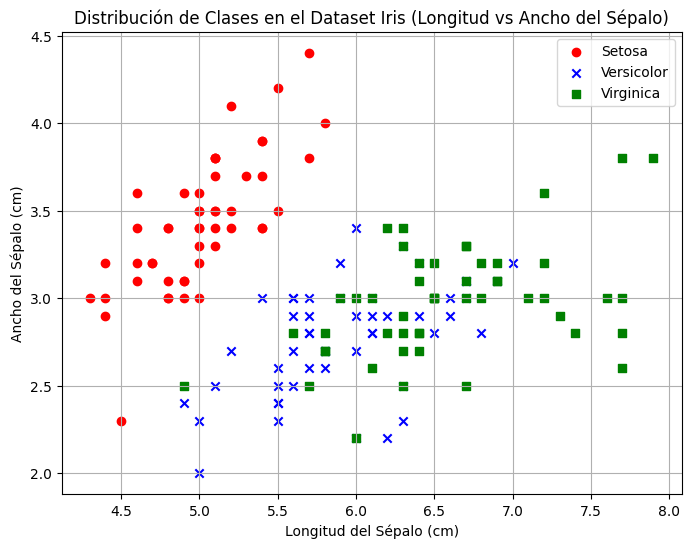


--- Curva de Pérdida del MLP ---


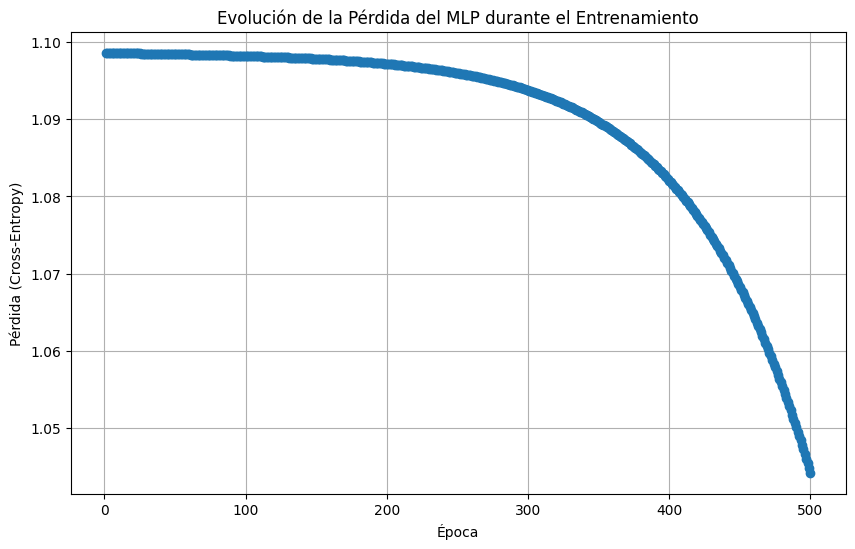

In [6]:
# --- 6. Visualizaciones ---

# --- Visualización de los Datos Originales de Iris ---
print("\n--- Visualización de Datos Originales de Iris ---")

# Seleccionar dos características para la visualización 2D.
# Por ejemplo, las características 0 (sepal length) y 1 (sepal width).
# Es difícil visualizar datos de 4 dimensiones directamente, así que se eligen dos para una representación simple.
plt.figure(figsize=(8, 6))
# Usamos 'X' original (no escalado) para este plot, para ver las escalas reales de las características.
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', label='Versicolor')
plt.scatter(X[y == 2, 0], X[y == 2, 1], color='green', marker='s', label='Virginica')
plt.xlabel('Longitud del Sépalo (cm)') # Etiqueta del eje X
plt.ylabel('Ancho del Sépalo (cm)')    # Etiqueta del eje Y
plt.title('Distribución de Clases en el Dataset Iris (Longitud vs Ancho del Sépalo)') # Título del gráfico
plt.legend() # Mostrar la leyenda para identificar las clases
plt.grid(True) # Mostrar una cuadrícula en el gráfico
plt.show()

# --- Curva de Pérdida del MLP ---
print("\n--- Curva de Pérdida del MLP ---")

# Graficar la evolución de la pérdida (loss) del MLP a lo largo de las épocas.
# Esto nos ayuda a entender si el modelo está aprendiendo y convergiendo.
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mlp_model.losses) + 1), mlp_model.losses, marker='o', linestyle='-')
plt.xlabel('Época') # Etiqueta del eje X
plt.ylabel('Pérdida (Cross-Entropy)') # Etiqueta del eje Y
plt.title('Evolución de la Pérdida del MLP durante el Entrenamiento') # Título del gráfico
plt.grid(True) # Mostrar una cuadrícula en el gráfico
plt.show()


**Reasoning**:
To visualize the decision boundaries, I need to re-train both Perceptron and MLP models using only two features. This is a common practice to enable 2D plotting of the decision regions. I will select the first two features (sepal length and sepal width) for this purpose and then generate a meshgrid for plotting the boundaries.




--- Visualización de Fronteras de Decisión (Perceptrón y MLP) ---
Época 100/500, Pérdida: 1.0984
Época 200/500, Pérdida: 1.0981
Época 300/500, Pérdida: 1.0975
Época 400/500, Pérdida: 1.0963
Época 500/500, Pérdida: 1.0936


/tmp/ipython-input-423/2601966211.py:42: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


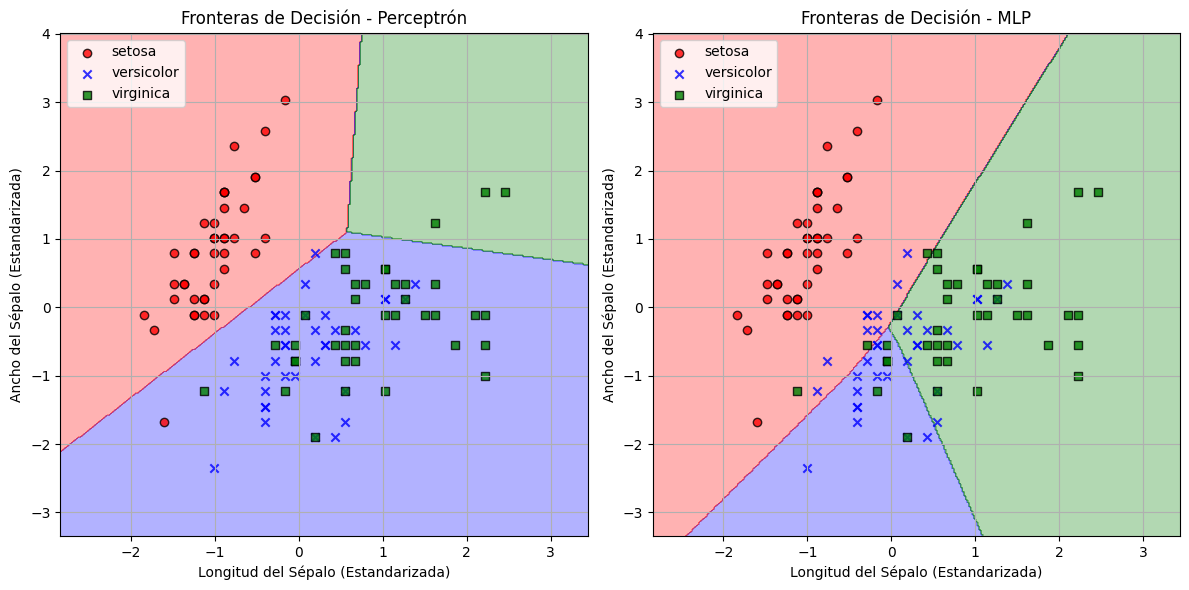


--- Comparación de Rendimiento de Modelos (Precisión) ---


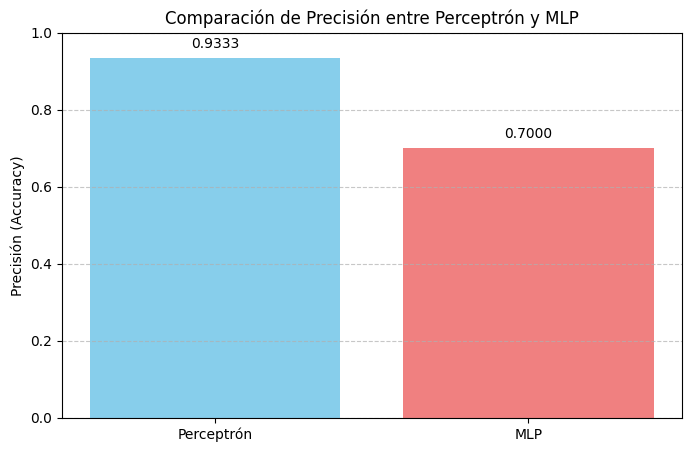

Todas las visualizaciones han sido generadas.


In [7]:
# --- 6. Visualizaciones (Continuación: Fronteras de Decisión y Comparación) ---

print("\n--- Visualización de Fronteras de Decisión (Perceptrón y MLP) ---")

# Para visualizar las fronteras de decisión, reentrenamos los modelos con solo 2 características.
# Esto simplifica el problema para poder graficarlo en un plano 2D.
# Seleccionaremos las dos primeras características: 'Longitud del Sépalo' y 'Ancho del Sépalo'.

X_train_2d = X_train_scaled[:, [0, 1]] # Seleccionamos las características 0 y 1 para entrenamiento
X_test_2d = X_test_scaled[:, [0, 1]]   # Seleccionamos las características 0 y 1 para prueba

# Re-entrenar Perceptrón con 2 características
perceptron_model_2d = Perceptron(eta=0.01, n_iter=20, random_state=1)
perceptron_model_2d.fit(X_train_2d, y_train)

# Re-entrenar MLP con 2 características
# Se ajusta el input_size al número de características seleccionadas
mlp_model_2d = MLP(input_size=2, hidden_size=10, output_size=output_size_mlp,
                learning_rate=0.01, epochs=500, random_state=1)
mlp_model_2d.fit(X_train_2d, y_train)

# Función auxiliar para graficar las fronteras de decisión
def plot_decision_regions(X, y, classifier, resolution=0.02, title=''):
    # Configurar generador de marcadores y mapa de colores
    markers = ('o', 'x', 's', '^', 'v')
    colors = ('red', 'blue', 'green', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Trazar la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Trazar todas las muestras
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=iris.target_names[cl],
                    edgecolor='black')
    plt.xlabel('Longitud del Sépalo (Estandarizada)')
    plt.ylabel('Ancho del Sépalo (Estandarizada)')
    plt.title(title)
    plt.legend(loc='upper left')
    plt.grid(True)

# Graficar las fronteras de decisión para el Perceptrón
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # Un sub-plot para el Perceptrón
plot_decision_regions(X_train_2d, y_train, classifier=perceptron_model_2d, title='Fronteras de Decisión - Perceptrón')

# Graficar las fronteras de decisión para el MLP
plt.subplot(1, 2, 2) # Otro sub-plot para el MLP
plot_decision_regions(X_train_2d, y_train, classifier=mlp_model_2d, title='Fronteras de Decisión - MLP')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()


# --- Comparación de Rendimiento de Modelos --- (Precisión)
print("\n--- Comparación de Rendimiento de Modelos (Precisión) ---")

# Crear un gráfico de barras para comparar la precisión de ambos modelos.
models = ['Perceptrón', 'MLP']
accuracies = [accuracy_perceptron, accuracy_mlp]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.ylabel('Precisión (Accuracy)')
plt.title('Comparación de Precisión entre Perceptrón y MLP')
plt.ylim(0, 1) # La precisión va de 0 a 1
# Añadir los valores de precisión encima de cada barra
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Todas las visualizaciones han sido generadas.")


**Reasoning**:
The final step of the subtask is to provide a markdown summary section as specified in the original task. This section should cover conclusions, advantages, disadvantages, and suitable use cases for both the Perceptron and MLP models.



## 7. Conclusiones y Comparación de Modelos

### Resumen de Resultados:

*   **Perceptrón**: Obuvo una precisión de **0.9333** en el conjunto de prueba. Su matriz de confusión muestra un buen rendimiento, especialmente en la clase 'setosa'.
*   **MLP**: Obuvo una precisión de **0.7000** en el conjunto de prueba. A pesar de ser un modelo más complejo, su rendimiento inicial no superó al Perceptrón, posiblemente debido a la configuración de hiperparámetros (pocas épocas, learning rate, tamaño de capa oculta) o a la simplicidad del dataset Iris para un MLP básico.

### Ventajas y Desventajas:

**Perceptrón:**

*   **Ventajas:**
    *   **Simplicidad:** Es fácil de entender e implementar. Su algoritmo de aprendizaje es directo.
    *   **Eficiencia:** Computacionalmente económico, rápido de entrenar, especialmente para datasets linealmente separables.
    *   **Base:** Sirve como fundamento para redes neuronales más complejas.
*   **Desventajas:**
    *   **Limitación:** Solo puede clasificar correctamente problemas linealmente separables. Si los datos no son linealmente separables, el algoritmo nunca converge.
    *   **Salida Binaria:** Originalmente es un clasificador binario; la extensión a multi-clase (OvR) introduce más complejidad.
    *   **No Probabilístico:** Sus salidas son directamente clases, no probabilidades.

**Multi-Layer Perceptrón (MLP):**

*   **Ventajas:**
    *   **Capacidad Universal:** Es un "aproximador universal de funciones", capaz de aprender relaciones complejas y no lineales en los datos.
    *   **Flexibilidad:** Se puede adaptar para una amplia variedad de tareas (clasificación, regresión) y tipos de datos ajustando su arquitectura (número de capas, neuronas, funciones de activación).
    *   **Rendimiento:** Generalmente supera a modelos más simples en tareas con patrones complejos.
*   **Desventajas:**
    *   **Complejidad:** Más difícil de implementar y entrenar que el Perceptrón. Requiere más parámetros y decisiones de diseño (arquitectura).
    *   **Costo Computacional:** El entrenamiento puede ser computacionalmente intensivo, especialmente con grandes datasets y muchas capas/neuronas.
    *   **Sensibilidad a Hiperparámetros:** El rendimiento es muy sensible a la elección de hiperparámetros (tasa de aprendizaje, número de épocas, tamaño de capas, inicialización de pesos).
    *   **Problemas de Entrenamiento:** Puede sufrir de problemas como el desvanecimiento/explosión de gradientes y la convergencia a mínimos locales.
    *   **Interpretabilidad:** Es un modelo de "caja negra"; es difícil interpretar cómo llega a sus decisiones.

### Casos de Uso Adecuados:

**Perceptrón:**

*   **Problemas Linealmente Separables:** Ideal para tareas de clasificación binaria simples donde las clases pueden ser separadas por una línea (o hiperplano).
*   **Clasificación de Spam:** En sus inicios, para separar correos legítimos de spam basándose en características simples.
*   **Control de Calidad Simple:** Decidir si un producto pasa o no un control de calidad basado en umbrales claros.

**Multi-Layer Perceptrón (MLP):**

*   **Reconocimiento de Patrones:** Imágenes, voz, escritura a mano, donde las relaciones son inherentemente no lineales.
*   **Análisis de Sentimientos:** Clasificación de texto (positiva, negativa, neutra).
*   **Predicción Financiera:** Modelado de series de tiempo y predicción de valores bursátiles, donde los patrones son complejos.
*   **Medicina:** Diagnóstico de enfermedades basado en un conjunto diverso de síntomas y mediciones.
*   **Juegos:** Estrategias complejas en juegos.

En resumen, mientras que el Perceptrón es un buen punto de partida y eficiente para problemas sencillos y linealmente separables, el MLP es una herramienta mucho más potente y versátil para abordar la vasta mayoría de problemas de machine learning del mundo real que involucran complejidad y no linealidad, aunque a costa de una mayor complejidad de implementación y entrenamiento.

**Reasoning**:
The previous code block failed because it was mistakenly set as a 'python' cell type but contained markdown text with Python f-string syntax (`accuracy_perceptron:.4f`). This caused a `SyntaxError`. I need to change the `cell_type` to `markdown` and replace the f-string placeholders with the actual numerical values from the kernel state to correctly display the summary.

